### Package import module

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import special
from scipy import signal
from numba import jit
from scipy.special import erf
from scipy import special
import math
import numba
import time
from matplotlib.colors import LogNorm
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter
from scipy.signal import welch
from scipy.stats import linregress

### Parameters and spectral radius calculations

Variance of connectivity matrix (num, theo): 8.505811059357398e-06 8.745749999999998e-06
Mean of connectivity matrix (should be as close to zero as possible): 2.4980018054066023e-22
Theoretical spectral radius: 0.6670959848173142


/tmp/ipython-input-3457225375.py:94: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x,np.sqrt(rad_o_theo**2-(x-d)**2),color='black',linewidth=3, alpha=1)
/tmp/ipython-input-3457225375.py:95: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x,-np.sqrt(rad_o_theo**2-(x-d)**2),color= 'black',linewidth=3,alpha=1)
/tmp/ipython-input-3457225375.py:96: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x,np.sqrt(rad_o_theo_noise**2-(x-d)**2),color='red',linewidth=3, alpha=1)
/tmp/ipython-input-3457225375.py:97: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x,-np.sqrt(rad_o_theo_noise**2-(x-d)**2),color= 'red',linewidth=3,alpha=1)


Text(0.5, 0, 'Real Part')

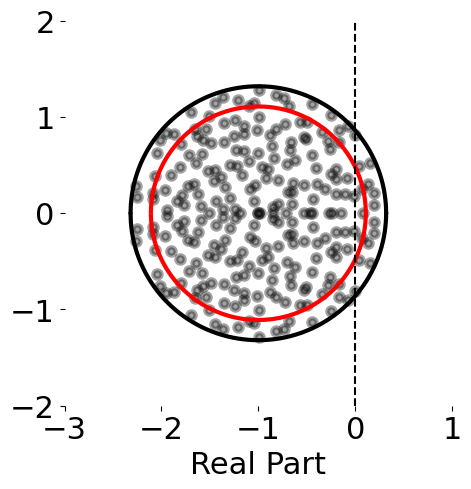

In [9]:
N=250
d=-1
beta=50
kappa=1.95
sigma_h=0.0
B=-0.00 #-0.05
rho =0.05 #0.05 #connectoin probability
f=0.8#proportion of e vs i cells/cortical
sigma_e_2 = 0.000045#0.00007
sigma_i_2 = 0.000045#0.00007
#AXEL: INCREASE MU_E TO INCREASE INSTABILITY AND FLUCTUATIONS AMPLITUDE
mu_e= 0.0005 #0.0005 so that the variance scales like 1/N
mu_i= -f/(1-f)*mu_e

W = np.zeros((N,N))
M_e=np.random.normal(mu_e, np.sqrt(sigma_e_2), size=(N,N))
M_i=np.random.normal(mu_i, np.sqrt(sigma_i_2), size=(N,N))

List = np.zeros(N);
for i in range(N):
  for j in range(N):
    P_connectivity = np.random.rand()
    if (P_connectivity<rho):
      if (j<int(f*N)):
        List[j] = M_e[i][j];
      else:
        List[j] = M_i[i][j];
    else:
      List[j] = 0;
  np.random.shuffle(List)
  for j in range(N):
    if i==j:
      W[i][j]=0
    else:
      W[i][j]=List[j]
row_sum=np.zeros(N)
for i in range(N):
  row_sum[i] =(np.sum(W[i][:]))
  number_of_nonzero_entries=0
  for j in range(N):
    if W[i][j]!=0:
      number_of_nonzero_entries = number_of_nonzero_entries+1
  for j in range(N):
    if W[i][j]!=0:
      W[i][j]=W[i][j]-row_sum[i]/number_of_nonzero_entries

threshold = np.zeros(N)
for i in range(N):
  threshold[i] = np.sqrt(sigma_h)*np.random.normal(0,1)

#variance connectivity matrix - scales like 1/N by construction
sigma_2 = kappa**2*rho*(f*sigma_e_2+(1-f)*sigma_i_2+f/(1-f)*mu_e**2)
print("Variance of connectivity matrix (num, theo):", np.var(kappa*W),sigma_2)
print("Mean of connectivity matrix (should be as close to zero as possible):",np.mean(W))


#theoretical steady state pdf variances

#IF STABLE/////////////////////////////////////////////////////////////////////////////

#Jacobian
J_o = np.zeros((N,N))
J = np.zeros((N,N))
for i in range(N):
  for j in range(N):
    J_o[i][j] = kappa*W[i][j]*beta/np.sqrt(np.pi)*np.exp(-beta**2*(0*+0*threshold[j])**2)
    # J_o[i][j] = W[i][j]*beta/np.sqrt(np.pi)*np.exp(-beta**2*(0)**2)


#spectral radius
Var_J_o = np.var(J_o)
rad_o = np.sqrt(N*Var_J_o)
sigma_u_theo = N * np.var(W) * (np.sqrt(np.pi ** 2 * sigma_h * beta ** 2 + 4) - 2) * (np.pi ** 2 * sigma_h * beta ** 2 + 4) ** (-0.1e1 / 0.2e1) / 4
gamma1 = 1+4*beta**2*(0*sigma_u_theo+0*sigma_h)
rad_o_theo = np.sqrt(N*sigma_2*beta**2/(np.pi*np.sqrt(gamma1))*np.exp(-beta**2*(0)**2/(gamma1))**2)

gamma1_noise = 1+4*beta**2*(0.0001)
rad_o_theo_noise =  np.sqrt(N*1**2*sigma_2*beta**2/(np.pi*np.sqrt(gamma1_noise))*np.exp(-beta**2*(0)**2/(gamma1_noise))**2)

print("Theoretical spectral radius:", np.sqrt(N*np.var(W)*beta**2/(np.pi*np.sqrt(gamma1))*np.exp(-beta**2*(0)**2/(gamma1))**2))



eigenvalues_o = np.linalg.eigvals(J_o)
X_o=eigenvalues_o.real
Y_o=eigenvalues_o.imag

plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(5,5))
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
x=np.arange(-15,15,0.001)

plt.plot(x,np.sqrt(rad_o_theo**2-(x-d)**2),color='black',linewidth=3, alpha=1)
plt.plot(x,-np.sqrt(rad_o_theo**2-(x-d)**2),color= 'black',linewidth=3,alpha=1)
plt.plot(x,np.sqrt(rad_o_theo_noise**2-(x-d)**2),color='red',linewidth=3, alpha=1)
plt.plot(x,-np.sqrt(rad_o_theo_noise**2-(x-d)**2),color= 'red',linewidth=3,alpha=1)
plt.scatter(X_o-1,Y_o, color='black',alpha=0.2,linewidth=3)
plt.scatter(X_o-1,Y_o, color='black',alpha=0.2,linewidth=3)
plt.xlim(-3,1)
plt.ylim(-2,2)
plt.axvline(x=0,color='k', linestyle='--')
plt.xlabel('Real Part')



Text(0.5, 1.0, 'Connectivity Matrix W')

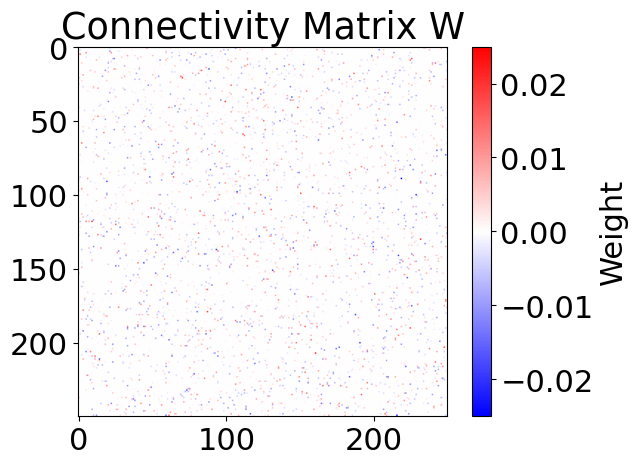

In [10]:
plt.imshow(W, cmap='bwr', vmin=-np.max(np.abs(W)), vmax=np.max(np.abs(W)))
plt.colorbar(label='Weight')
plt.title('Connectivity Matrix W')

### Functions definition

In [11]:
@numba.njit()
def F(u,h):
  output =0.5*(1+math.erf(beta*(u+h)))#np.tanh(beta*u)# 1/(1+np.exp(-beta*u))
  return output


def fcnForNumba1(T, dt):
  #arrays for network dynamics

  time=np.arange(0,T)
  print(time.shape)
  #environmental perturbations

  perturbations = np.zeros(time.shape)
  filtered_noise_1 = np.zeros(time.shape)
  filtered_noise_2 = np.zeros(time.shape)
  filtered_noise_3 = np.zeros(time.shape)
  Noise=10#0.05 #0.2
  for t in range(len(time)-1):
    perturbations[t+1] = perturbations[t]+dt*0.001*(-perturbations[t]+filtered_noise_1[t])
    filtered_noise_1[t+1]= filtered_noise_1[t]+dt*0.005*(-1*filtered_noise_1[t]+filtered_noise_2[t])
    filtered_noise_2[t+1]= filtered_noise_2[t]+dt*0.005*(-1*filtered_noise_2[t]+filtered_noise_3[t])
    filtered_noise_3[t+1]= filtered_noise_3[t]+dt*0.05*(-1*filtered_noise_3[t])+np.sqrt(2*Noise*dt)*np.random.normal(0,1)
  return perturbations
@numba.njit()
def fcnForNumba2(perturbations, D1, D2, D3, D4, D5, kappa, W, N, T, dt):
  #arrays for network dynamics
  time=np.arange(0,T)
  o = np.zeros((N,time.shape[0]))
  u = np.zeros((N,time.shape[0]))
  v= np.zeros((N,time.shape[0]))
  w= np.zeros((N,time.shape[0]))
  z= np.zeros((N,time.shape[0]))
  threshold = np.zeros(N)
  #Euler integration
  for i in range(N):

    u[i][0] = 0.05*np.random.normal(0,1)
    o[i][0] = u[i][0]
    v[i][0] = u[i][0]
    w[i][0] = u[i][0]
    z[i][0] = u[i][0]

  for t in range(time.shape[0]-1):
    for i in range(N):
      sum0=0
      sum=0
      sum2=0
      sum3=0
      sum4=0
      for j in range(N):
        sum0=sum0+kappa*W[i][j]*F(o[j][t],threshold[j])
        sum=sum+kappa*W[i][j]*F(u[j][t],threshold[j])
        sum2=sum2+kappa*W[i][j]*F(v[j][t],threshold[j])
        sum3=sum3+kappa*W[i][j]*F(w[j][t],threshold[j])
        sum4=sum4+kappa*W[i][j]*F(z[j][t],threshold[j])

      o[i][t+1] = o[i][t] +dt*(-o[i][t]+sum0+B)+np.sqrt(2*np.abs(perturbations[t])*D1*dt)*np.random.normal(0,1)
      u[i][t+1] = u[i][t] +dt*(-u[i][t]+sum+B)+np.sqrt(2*np.abs(perturbations[t])*D2*dt)*np.random.normal(0,1)
      v[i][t+1] = v[i][t] +dt*(-v[i][t]+sum2+B)+np.sqrt(2*np.abs(perturbations[t])*D3*dt)*np.random.normal(0,1)
      w[i][t+1] = w[i][t] +dt*(-w[i][t]+sum3+B)+np.sqrt(2*np.abs(perturbations[t])*D4*dt)*np.random.normal(0,1)
      z[i][t+1] = z[i][t] +dt*(-z[i][t]+sum4+B)+np.sqrt(2*np.abs(perturbations[t])*D5*dt)*np.random.normal(0,1)


  return o, u, v, w, z

## Load the Data

In [12]:
data =np.load('figure1.npz') # Assuming figure1.npz is uploaded to the current working directory
mean_1=data['mean_1']
mean_2=data['mean_2']
mean_3=data['mean_3']
mean_4=data['mean_4']
mean_5=data['mean_5']
perturbations=data['perturbations']
o=data['o']
v=data['v']
w=data['w']
u=data['u']
z=data['z']
time=data['time']
eigenvalues_o=data['eigenvalues_o']
rad_o=data['rad_o']
rad_o_theo=data['rad_o_theo']
rad_o_theo_noise=data['rad_o_theo_noise']
X_o=data['X_o']
Y_o=data['Y_o']

In [7]:
from google.colab import files

# This will open a file selection dialog. Please select 'figure1.npz'
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')


Saving figure1.npz to figure1.npz
User uploaded file "figure1.npz"


In [14]:
data =np.load('figure1.npz') # Now the file should be in the Colab environment after upload
mean_1=data['mean_1']
mean_2=data['mean_2']
mean_3=data['mean_3']
mean_4=data['mean_4']
mean_5=data['mean_5']
perturbations=data['perturbations']
o=data['o']
v=data['v']
w=data['w']
u=data['u']
z=data['z']
time=data['time']
eigenvalues_o=data['eigenvalues_o']
rad_o=data['rad_o']
rad_o_theo=data['rad_o_theo']
rad_o_theo_noise=data['rad_o_theo_noise']
X_o=data['X_o']
Y_o=data['Y_o']

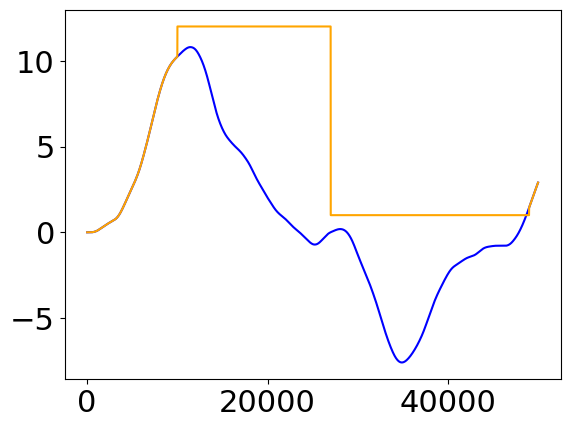

In [15]:
perturbations2 = perturbations.copy()
perturbations2[10000:27000] = 12
perturbations2[27000:49000] = 1
# perturbations2 = perturbations[0:T]
plt.plot(perturbations, color='blue')
plt.plot(perturbations2, color='orange')

### Spectral analysis

In [16]:
fs = 1000
window_size =2048 #2048*2
size = int(window_size/2+1)
p_mean = np.zeros(size)
p_var = np.zeros(size)
freq_mean = np.zeros(size)
p_mean2 = np.zeros(size)
p_var2 = np.zeros(size)
freq_mean2 = np.zeros(size)
p_mean3 = np.zeros(size)
freq_mean3 = np.zeros(size)
p_var3 = np.zeros(size)
p_mean4 = np.zeros(size)
freq_mean4 = np.zeros(size)
p_var4 = np.zeros(size)
freq_mean5 = np.zeros(size)
p_mean5 = np.zeros(size)
p_var5 = np.zeros(size)
PSD1 = np.zeros((N,size))
PSD2 = np.zeros((N,size))
PSD3 = np.zeros((N,size))
PSD4 = np.zeros((N,size))
PSD5 = np.zeros((N,size))
for i in range(N):
  f1= np.zeros(size)
  p1= np.zeros(size)
  f2= np.zeros(size)
  p2= np.zeros(size)
  f3= np.zeros(size)
  p3= np.zeros(size)
  f4= np.zeros(size)
  p4= np.zeros(size)
  f5= np.zeros(size)
  p5= np.zeros(size)
  sig = o[i][int(len(time)/4):len(time)]
  sig2 = u[i][int(len(time)/4):len(time)]
  sig3 = v[i][int(len(time)/4):len(time)]
  sig4 = w[i][int(len(time)/4):len(time)]
  sig5 = z[i][int(len(time)/4):len(time)]
  f1, p1 = signal.welch(sig, fs, nperseg=window_size)
  f2, p2 = signal.welch(sig2, fs, nperseg=window_size)
  f3, p3 = signal.welch(sig3, fs, nperseg=window_size)
  f4, p4 = signal.welch(sig4, fs, nperseg=window_size)
  f5, p5 = signal.welch(sig5, fs, nperseg=window_size)
  PSD1[i,:] = p1
  PSD2[i,:] = p2
  PSD3[i,:] = p3
  PSD4[i,:] = p4
  PSD5[i,:] = p5
  for k in range(size):
    p_mean[k] = p_mean[k]+1/N*p1[k]
    freq_mean[k] = f1[k]
    p_mean2[k] = p_mean2[k]+1/N*p2[k]
    freq_mean2[k] = f2[k]
    p_mean3[k] = p_mean3[k]+1/N*p3[k]
    freq_mean3[k] = f3[k]
    p_mean4[k] = p_mean4[k]+1/N*p4[k]
    freq_mean4[k] = f4[k]
    p_mean5[k] = p_mean5[k]+1/N*p5[k]
    freq_mean5[k] = f5[k]

for k in range(size):
  p_var[k] = np.std(PSD1[:,k])
  p_var2[k] = np.std(PSD2[:,k])
  p_var3[k] = np.std(PSD3[:,k])
  p_var4[k] = np.std(PSD4[:,k])
  p_var5[k] = np.std(PSD5[:,k])



In [18]:
print(T)
Time = np.linspace(0, 50, int(T))
Nodes = np.random.randint(0,v.shape[1],20)
col = plt.cm.gray(np.linspace(0,1,len(Nodes)))
PP = slice(25000,27000)
plt.figure()
for i, node in enumerate(Nodes):
    plt.plot(Time[PP], v[i,PP], color = col[i], label='D=0.001')
plt.savefig('Fig1_supplementary_D001.png',dpi=300)
PP = slice(32000,34000)
plt.figure()
for i, node in enumerate(Nodes):
    plt.plot(Time[PP], v[i,PP], color = col[i], label='D=0.001')
plt.savefig('Fig1_supplementary_D002.png',dpi=300)

NameError: name 'T' is not defined

### Plotting

1 is high noise, 5 is low noise


NameError: name 'T' is not defined

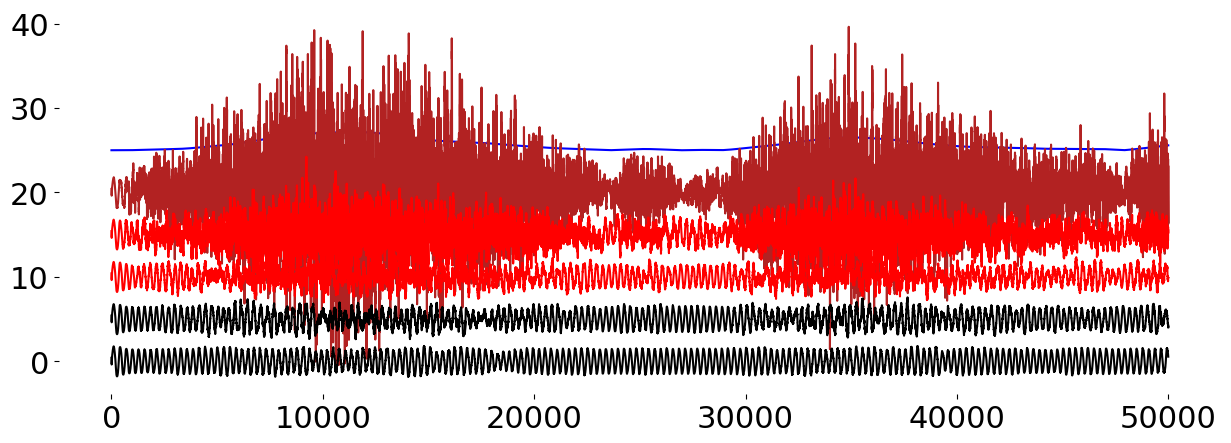

In [19]:
print("1 is high noise, 5 is low noise")
L =1000
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(15,5))
for pos in ['right', 'top', 'bottom', 'left']:
  plt.gca().spines[pos].set_visible(False)
colormap = plt.cm.gist_ncar
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Reds(np.linspace(0, 1, N))))
plt.plot(time,0.0002*L*(np.abs(perturbations))+25, color = "blue")
plt.plot(time,L*mean_1+20, color = "firebrick")
plt.plot(time,L*mean_2+15, color = "red")
plt.plot(time,L*mean_3+10, color = "red" )
plt.plot(time,L*mean_4+5, color = "black")
plt.plot(time,L*mean_5+0, color = "black")

plt.xlim(0, T)
plt.show()

plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(5,5))
for pos in ['right', 'top', 'bottom', 'left']:
  plt.gca().spines[pos].set_visible(False)
colormap = plt.cm.gist_ncar
plt.semilogy(freq_mean, p_mean,  color='firebrick',label = 'Low Noise (LN)')
plt.fill_between(freq_mean, p_mean - p_var, p_mean + p_var,color='red', alpha=0.2)
plt.semilogy(freq_mean2, p_mean2,  color='red',label = 'Low Noise (LN)')
plt.fill_between(freq_mean2, p_mean2 - p_var2, p_mean2 + p_var2,color='red', alpha=0.2)
plt.semilogy(freq_mean3, p_mean3,  color='red',label = 'Low Noise (LN)')
plt.fill_between(freq_mean3, p_mean3 - p_var3, p_mean3 + p_var3,color='red', alpha=0.2)
plt.semilogy(freq_mean4, p_mean4,  color='black',label = 'Low Noise (LN)')
plt.fill_between(freq_mean4, p_mean4 - p_var4, p_mean4 + p_var4,color='red', alpha=0.2)
plt.semilogy(freq_mean5, p_mean5, color='black', alpha=0.8,label = 'Disconnected LN $w_{ij}$=0')
plt.fill_between(freq_mean5, p_mean5 - p_var5, p_mean5 + p_var5,color='black', alpha=0.2)

plt.xlim([0,0.5*fs/10])
plt.ylim([0.5e-10, 1e-2])
plt.show()



### Plotting

/tmp/ipython-input-1603689834.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


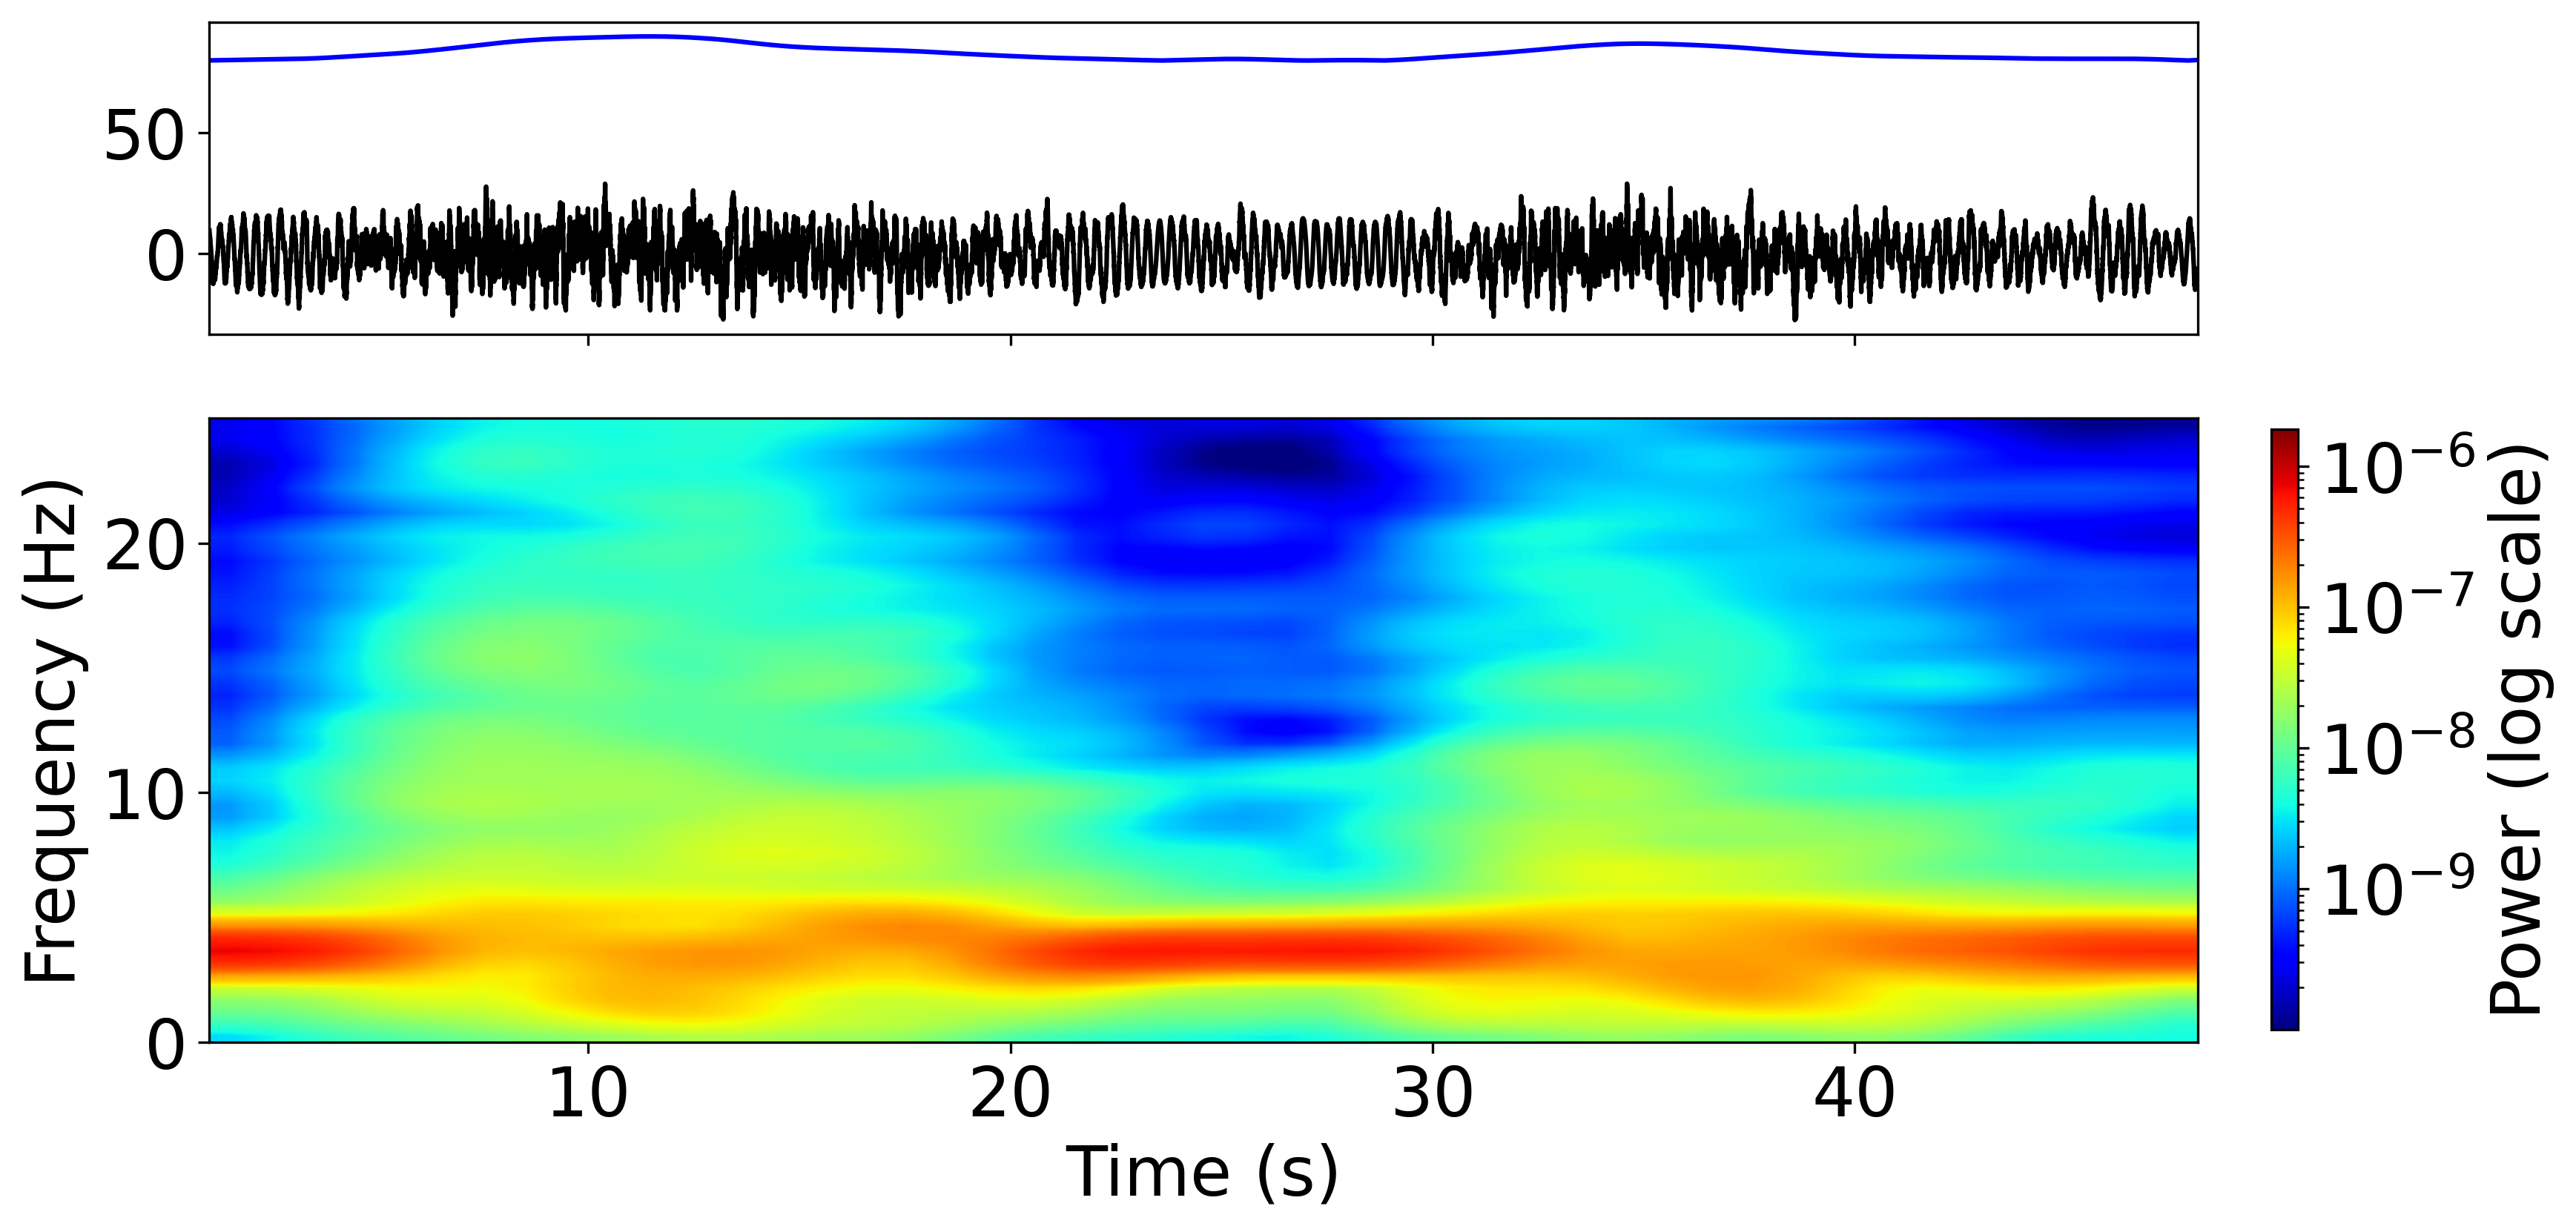

In [20]:
signalData1 = mean_3
Fs = 1000


NFFT = 2048
noverlap = 1024#NFFT // 2

# plt.figure(figsize=(12.5, 2))
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [1, 2]}, dpi=300)
ax0 = axes[0]
# for pos in ['right', 'top', 'bottom', 'left']:
    # ax0.spines[pos].set_visible(False)
ax0.plot(time[10:]* 1e-3,10*(np.abs(perturbations[10:])/np.max(perturbations[10:]))+80, color = "blue")
ax0.plot(time[10:]* 1e-3,10000*signalData1[10:], color = "black")
# ax0.set_yticks([])
ax0.set_xticks([])
# ax0.set_ylabel('')

ax1 = axes[1]
# Compute spectrogram using scipy.signal.spectrogram
freqs, times, Sxx = spectrogram(signalData1, fs=Fs, nperseg=NFFT, noverlap=noverlap)
smoothed_data = gaussian_filter(Sxx, sigma=[1, 1.5])

# plt.figure(figsize=(15,5))

# Plot spectrogram with log scaling on power using LogNorm
im = ax1.imshow(smoothed_data, aspect='auto', origin='lower',
           extent=[times.min(), times.max(),freqs.min(),freqs.max()],
           cmap='jet',
           norm=LogNorm(vmin=Sxx.min()+1e-10, vmax=Sxx.max()),
            interpolation='bilinear'
          )

# ax1.colorbar(label='Power (log scale)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Frequency (Hz)')
# ax1.spines['right'].set_visible(False)
# ax1.spines['top'].set_visible(False)
ax1.set_xticks([10,20,30,40])
ax1.set_xticklabels(['10','20','30','40'])
ax1.set_ylim(0, 25)  # your frequency limits
# --- Colorbar on the right of both plots ---
fig.subplots_adjust(right=0.87)
cbar_ax = fig.add_axes([0.87, 0.19, 0.01, 0.45])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Power (log scale)')
plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()

fig.savefig('Fig1.png',dpi=300  )


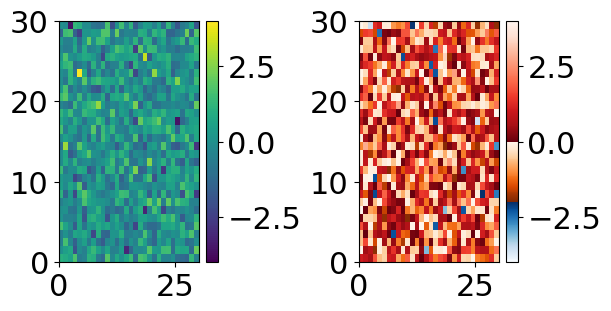

In [21]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
def plot_examples(colormaps):
    """
    Helper function to plot data with associated colormap.
    """
    np.random.seed(19680801)
    data = np.random.randn(30, 30)
    n = len(colormaps)
    fig, axs = plt.subplots(1, n, figsize=(n * 2 + 2, 3),
                            layout='constrained', squeeze=False)
    for [ax, cmap] in zip(axs.flat, colormaps):
        psm = ax.pcolormesh(data, cmap=cmap, rasterized=True, vmin=-4, vmax=4)
        fig.colorbar(psm, ax=ax)
    plt.show()
viridis = mpl.colormaps['viridis'].resampled(128)
top = mpl.colormaps['Blues'].resampled(64)
middle = mpl.colormaps['Oranges_r'].resampled(64)
bottom = mpl.colormaps['Reds_r'].resampled(128)

newcolors = np.vstack((top(np.linspace(0, 1, 64)),
                       middle(np.linspace(0, 1, 64)),
                       bottom(np.linspace(0, 1, 128))))
newcmp = ListedColormap(newcolors, name='OrangeBlue')
plot_examples([viridis, newcmp])

/tmp/ipython-input-371932262.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=0.3, rect=[0, 0, 0.87, 1])


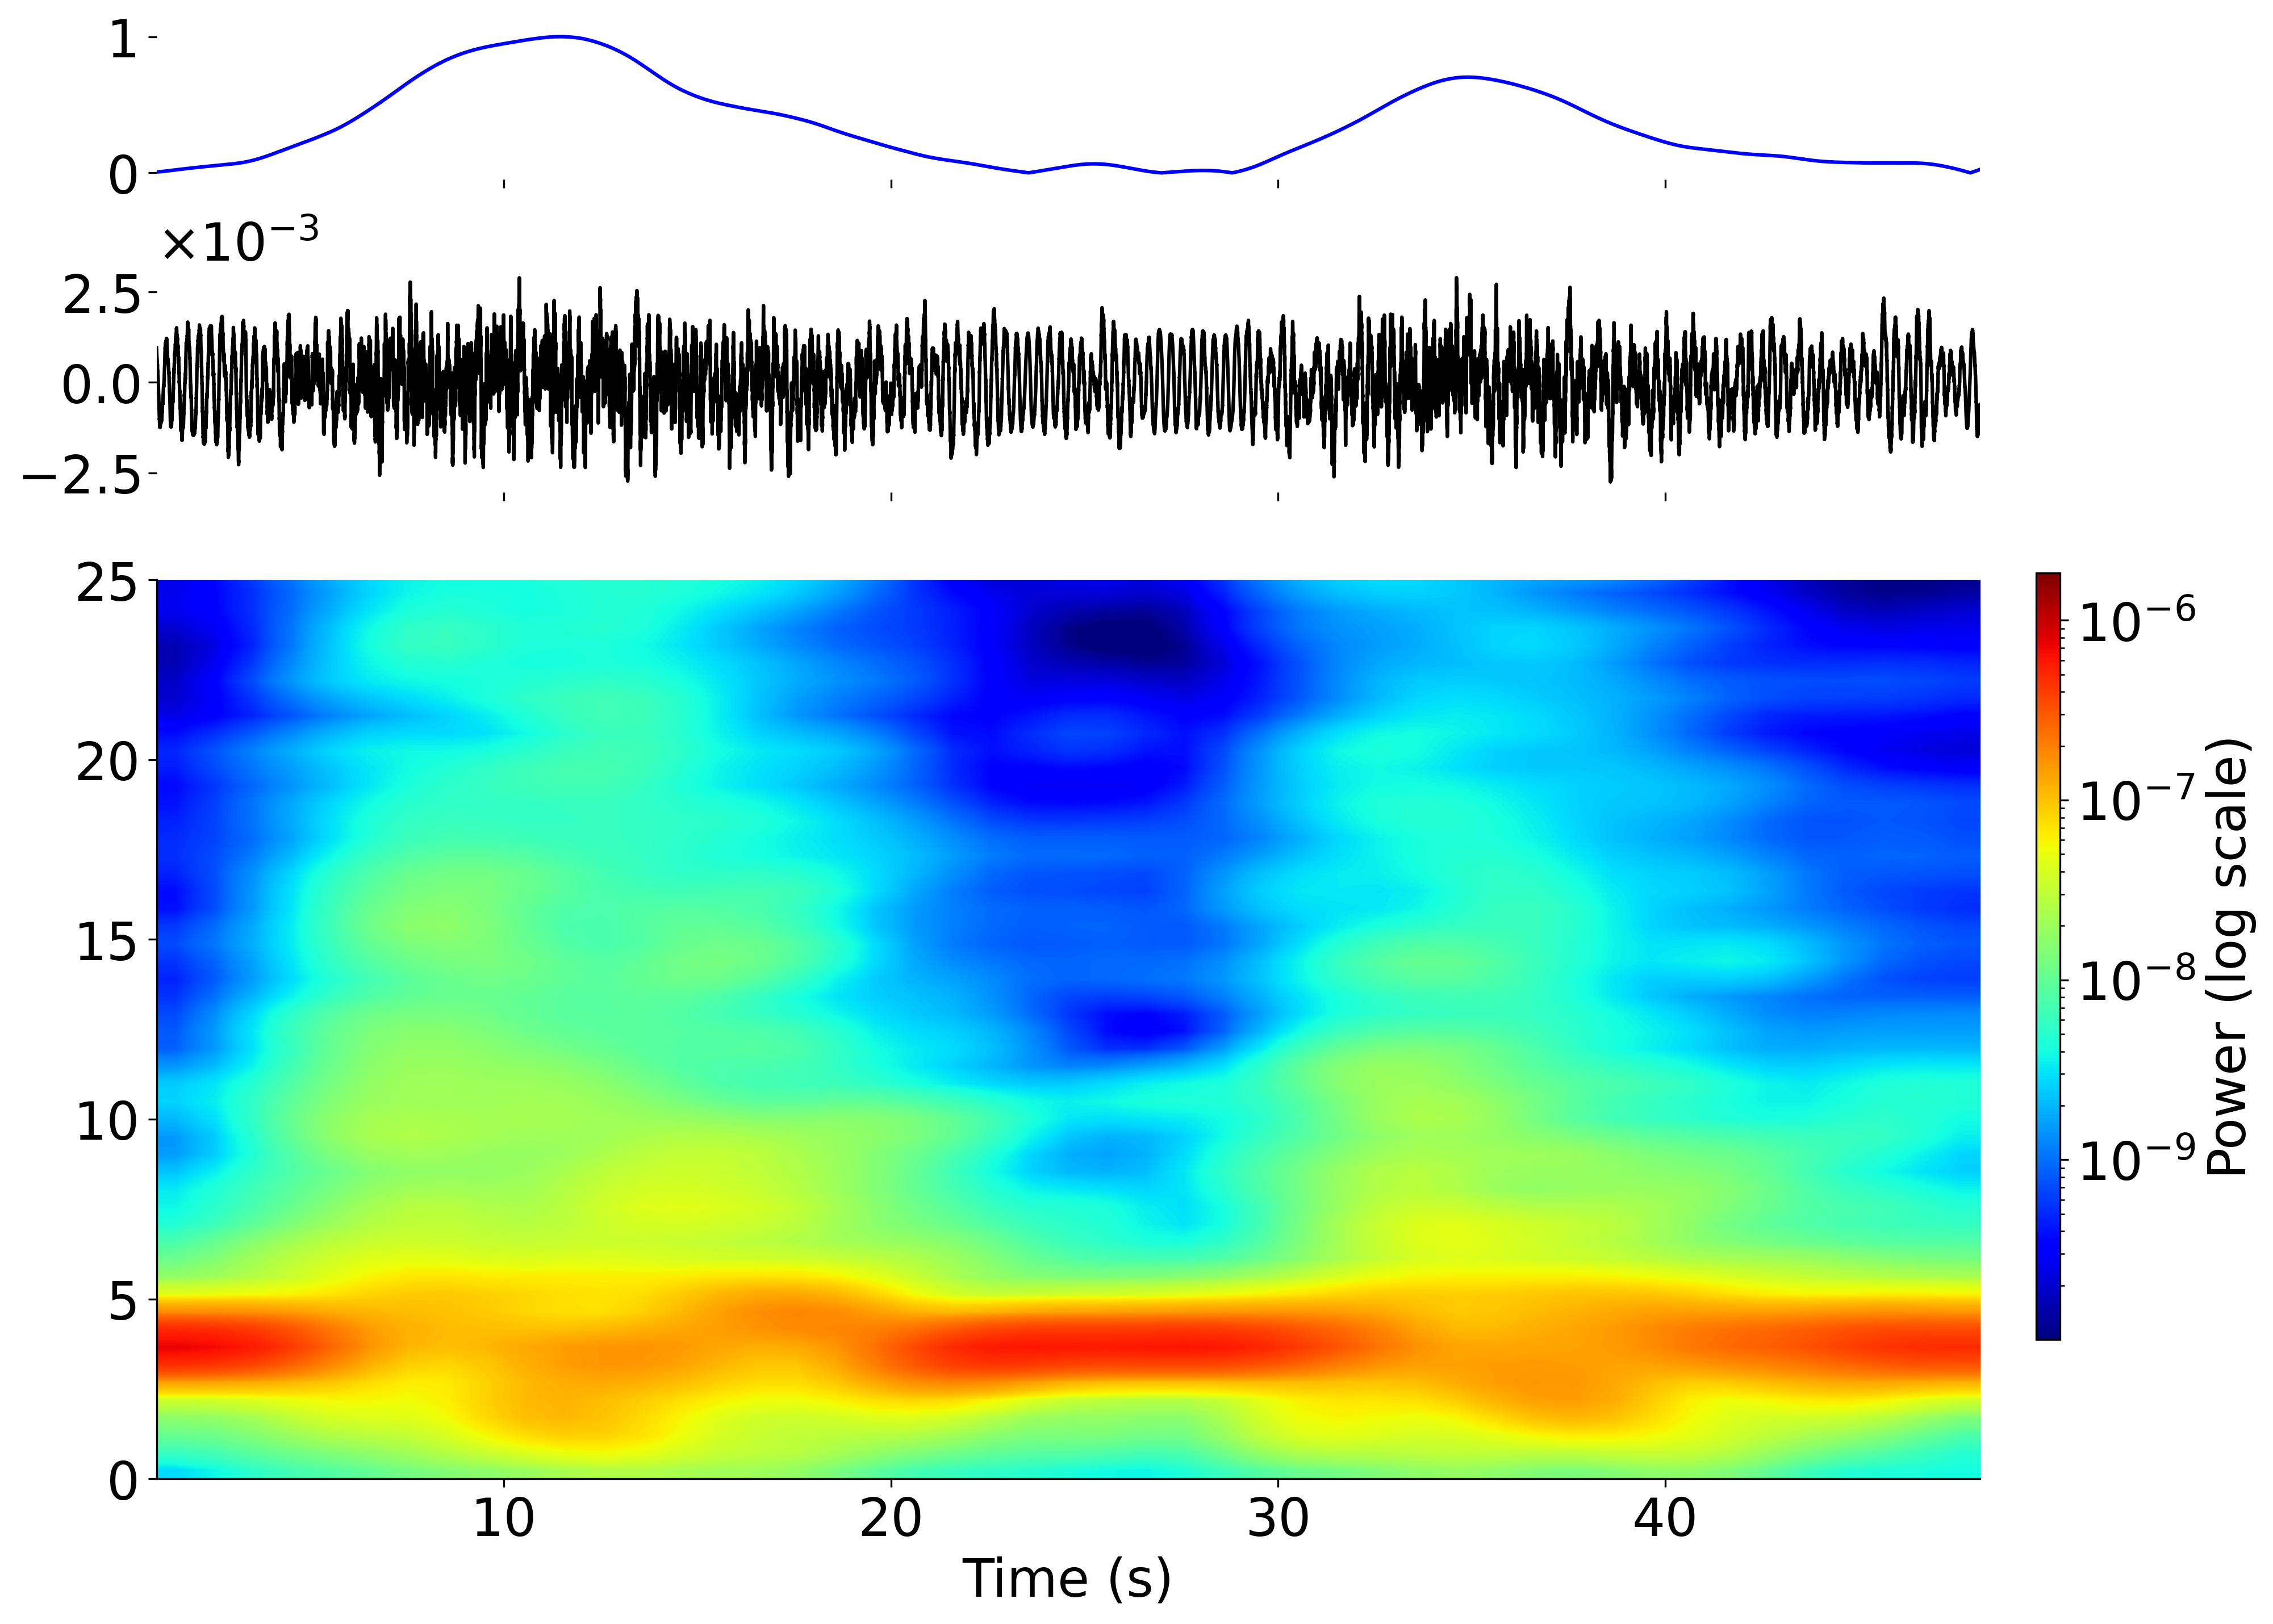

In [25]:
signalData1 = mean_3
Fs = 1000
from matplotlib.ticker import ScalarFormatter


NFFT = 2048
noverlap = 1024#NFFT // 2

# plt.figure(figsize=(12.5, 2))
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1.5, 6]}, dpi=300)
ax0 = axes[0]
for pos in ['right', 'top', 'bottom', 'left']:
    ax0.spines[pos].set_visible(False)
ax0.plot(time[10:]* 1e-3,(np.abs(perturbations[10:])/np.max(perturbations[10:])), color = "blue")
ax1.set_xlabel('')
# ax0.set_ylabel('Noise')

ax0 = axes[1]
ax0.plot(time[10:]* 1e-3,signalData1[10:], color = "black")
# ax0.set_yticks([-2.5e-3,0,2.5e-3],['-2.5','0','2.5'])
ax0.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-3, -3))
ax0.set_xticks([])
# ax0.set_ylabel('Activity')
# ax0.set_ylabel('')
for pos in ['right', 'top', 'bottom', 'left']:
    ax0.spines[pos].set_visible(False)

ax1 = axes[2]
# Compute spectrogram using scipy.signal.spectrogram
freqs, times, Sxx = spectrogram(signalData1, fs=Fs, nperseg=NFFT, noverlap=noverlap)
smoothed_data = gaussian_filter(Sxx, sigma=[1, 1.5])

# plt.figure(figsize=(15,5))

# Plot spectrogram with log scaling on power using LogNorm
im = ax1.imshow(smoothed_data, aspect='auto', origin='lower',
           extent=[times.min(), times.max(),freqs.min(),freqs.max()],
           cmap='jet',
           norm=LogNorm(vmin=Sxx.min()+1e-10, vmax=Sxx.max()),
            interpolation='bilinear'
          )

# ax1.colorbar(label='Power (log scale)')
ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('Frequency (Hz)')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_xticks([10,20,30,40])
ax1.set_xticklabels(['10','20','30','40'])
ax1.set_ylim(0, 25)  # your frequency limits
# --- Colorbar on the right of both plots ---
fig.subplots_adjust(right=0.87)
cbar_ax = fig.add_axes([0.87, 0.19, 0.01, 0.45])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Power (log scale)')
plt.tight_layout(h_pad=0.3, rect=[0, 0, 0.87, 1])
plt.show()

fig.savefig('Fig1.png',dpi=300  )

### Calculate the 1/f slope

In [ ]:
# ----- PARAMETERS -----
Fs = 1000
NFFT = 1500
noverlap = NFFT // 2

# Select time windows (start, end) in seconds
time_windows_sec = [(30, 48),(12, 26)]
window_duration = time_windows_sec[0][1] - time_windows_sec[0][0]
window_samples = int(window_duration * Fs)

# Define frequency range to fit (Hz)
fit_range = (10, 30)

# ----- LOOP OVER TIME WINDOWS -----
for i, (start_sec, end_sec) in enumerate(time_windows_sec):
    start_idx = int(start_sec * Fs)
    end_idx = int(end_sec * Fs)
    segment = signalData1[start_idx:end_idx]

    # Compute power spectrum
    freqs, psd = welch(segment, fs=Fs, nperseg=window_samples)

    # Avoid log(0)
    psd[psd == 0] = np.min(psd[psd > 0]) * 1e-1

    # Log-log for regression
    log_freqs = np.log10(freqs+np.finfo(float).eps)
    log_psd = np.log10(psd+np.finfo(float).eps)

    # Fit line over selected range
    fit_mask = (freqs >= fit_range[0]) & (freqs <= fit_range[1])
    fit_freqs = freqs[fit_mask]
    fit_log_freqs = log_freqs[fit_mask]
    fit_log_psd = log_psd[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(fit_log_freqs, fit_log_psd)
    fit_line_log = slope * fit_log_freqs + intercept
    fit_line = 10**fit_line_log
    print('slope:', slope   )
    # PLOT
    fig = plt.figure(dpi=300)
    plt.scatter(freqs, psd, color="black", label="Power Spectrum")

    # Green line for the first plot, red for others
    line_color = "green" if i == 0 else "red"
    plt.plot(fit_freqs, fit_line, color=line_color, linewidth=4, label=f"Fit: slope = {slope:.2f}")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, 1000)
    plt.ylim(1e-14, 1e-5)
    plt.xlabel("Frequency (Hz)", fontsize=22)
    plt.ylabel("Power", fontsize=22)
    plt.tick_params(labelsize=22)

    # plt.title(f"Window {i+1}: {start_sec}s–{end_sec}s")
    # plt.legend()

    # Remove top/right spines
    ax = plt.gca()
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    plt.tight_layout()
    # plt.show()
    fig.savefig(f'PowerFreq{i}.png',dpi=300)